## Week 2: EDA

Team ds55 member: Yingxin Deng

This week tasks: 
1. Load a minimum of 6 months of dataset into pandas. (2025/12-2026/05)
2. Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.
3. Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).
4. Deliverable: Jupyter notebook 01_exploration.ipynb with basic EDA plots.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
files = [
    "CRMLSSold202512.csv",
    "CRMLSSold202601.csv",
    "CRMLSSold202602.csv",
    "CRMLSSold202603.csv",
    "CRMLSSold202604.csv",
    "CRMLSSold202605.csv"
]

df = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)

print(df.shape)

/var/folders/tf/71q912hd3fzd4yz1qccgzpcw0000gn/T/ipykernel_76601/1333224837.py:11: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f) for f in files],


(124404, 78)


In [7]:
print(df.columns.tolist())

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).

In [10]:
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]

print(df.shape)

(61727, 78)


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 61727 entries, 0 to 124400
Data columns (total 78 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 58063 non-null  str    
 1   ListAgentAOR                  61709 non-null  str    
 2   Flooring                      39242 non-null  str    
 3   ViewYN                        56432 non-null  object 
 4   WaterfrontYN                  36 non-null     object 
 5   BasementYN                    1455 non-null   object 
 6   PoolPrivateYN                 56894 non-null  object 
 7   OriginalListPrice             61591 non-null  float64
 8   ListingKey                    61727 non-null  int64  
 9   ListAgentEmail                61596 non-null  str    
 10  CloseDate                     61727 non-null  str    
 11  ClosePrice                    61727 non-null  float64
 12  ListAgentFirstName            61355 non-null  str    
 13  ListAgentLastNam

In [12]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,6.159100e+04,6.172700e+04,6.172700e+04,61718.000000,61718.000000,61697.000000,6.172700e+04,61727.000000,0.0,0.0,...,0.0,445.000000,0.0,55234.000000,6.064900e+04,37653.000000,59374.000000,44111.000000,6.064600e+04,0.0
mean,1.339445e+06,1.146687e+09,1.340106e+06,34.708615,-118.560570,2055.552918,1.267892e+06,41.436130,NaN,NaN,...,NaN,56.276404,NaN,1.351468,1.940905e+04,2.264521,2.005196,111.463261,3.859489e+05,NaN
std,5.195236e+06,1.276873e+07,7.307629e+06,1.802984,3.253774,1037.243701,1.524326e+06,57.529263,NaN,NaN,...,NaN,225.966677,NaN,0.477433,2.052488e+05,1.447379,3.327872,368.761236,1.843401e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,8.000000e+03,-39.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.299000e+05,1.144826e+09,6.200000e+05,33.753896,-119.063627,1386.000000,6.244800e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.392000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.150713e+09,8.900000e+05,34.077919,-118.017017,1826.000000,8.900000e+05,19.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.023000e+03,3.000000,2.000000,0.000000,7.263500e+03,NaN
75%,1.445000e+06,1.153674e+09,1.425000e+06,34.695388,-117.250670,2455.000000,1.399900e+06,53.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.900000e+03,3.000000,2.000000,136.000000,1.045400e+04,NaN
max,7.250000e+08,1.171669e+09,7.960000e+08,43.784440,118.140030,23314.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.000000,1.897474e+09,NaN


In [13]:
cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeAcres"
]
df[cols].isnull().sum()

ClosePrice                  0
LivingArea                 30
BedroomsTotal               0
BathroomsTotalInteger       1
LotSizeAcres             1083
dtype: int64

### Distribution plots

1. Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.
2. Real estate variables are often right-skewed and contain extreme outliers.
3. For visualization only, continuous variables are clipped at the 1st and 99th percentiles.
4. The original eda dataframe is not changed.

In [20]:
def clipped_series(series, lower=0.01, upper=0.99):
    clean = series.dropna()
    low, high = clean.quantile([lower, upper])
    return series.clip(lower=low, upper=high), low, high


def dollar_ticks(axis):
    axis.set_major_formatter(lambda value, pos: f"${value / 1_000_000:.1f}M")


def sqft_ticks(axis):
    axis.set_major_formatter(lambda value, pos: f"{value:,.0f} sqft")


def acres_ticks(axis):
    axis.set_major_formatter(lambda value, pos: f"{value:.1f} acres")

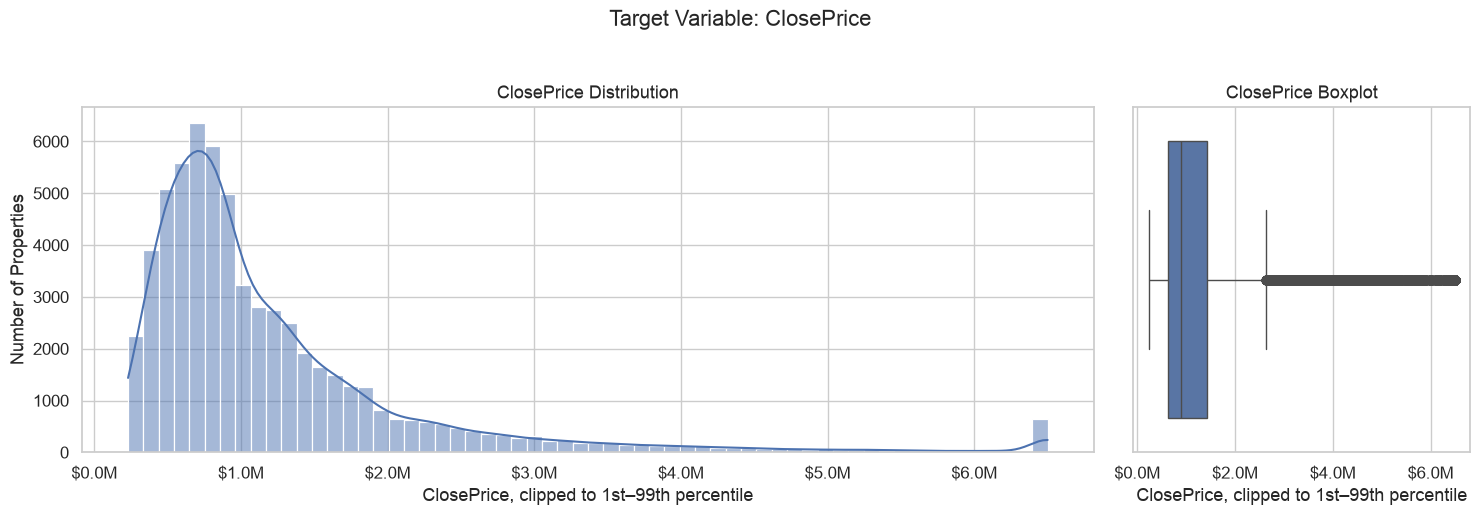

ClosePrice 1st percentile: $230,000
ClosePrice 99th percentile: $6,500,000


In [22]:
price_plot, price_p01, price_p99 = clipped_series(df["ClosePrice"])

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.histplot(
    price_plot,
    bins=60,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("ClosePrice Distribution")
axes[0].set_xlabel("ClosePrice, clipped to 1st–99th percentile")
axes[0].set_ylabel("Number of Properties")
dollar_ticks(axes[0].xaxis)

sns.boxplot(
    x=price_plot,
    ax=axes[1]
)

axes[1].set_title("ClosePrice Boxplot")
axes[1].set_xlabel("ClosePrice, clipped to 1st–99th percentile")
dollar_ticks(axes[1].xaxis)

fig.suptitle("Target Variable: ClosePrice", y=1.03)
plt.tight_layout()
plt.show()

print(f"ClosePrice 1st percentile: ${price_p01:,.0f}")
print(f"ClosePrice 99th percentile: ${price_p99:,.0f}")

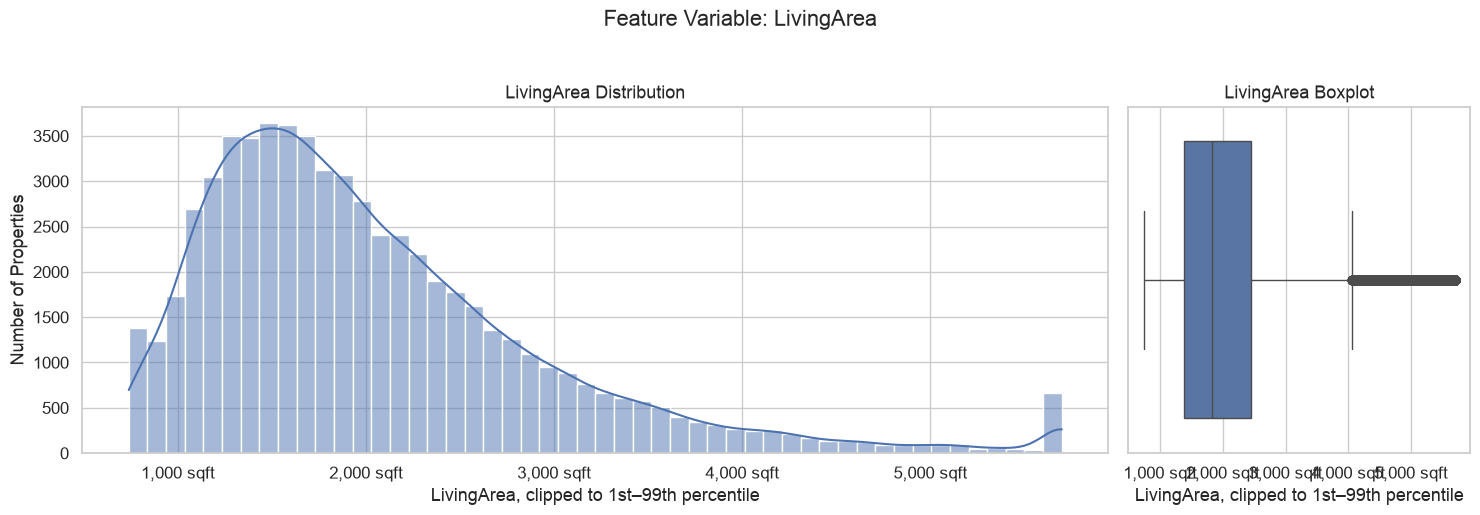

LivingArea 1st percentile: 738 sqft
LivingArea 99th percentile: 5,698 sqft


In [23]:
living_plot, living_p01, living_p99 = clipped_series(df["LivingArea"])

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.histplot(
    living_plot,
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("LivingArea Distribution")
axes[0].set_xlabel("LivingArea, clipped to 1st–99th percentile")
axes[0].set_ylabel("Number of Properties")
sqft_ticks(axes[0].xaxis)

sns.boxplot(
    x=living_plot,
    ax=axes[1]
)

axes[1].set_title("LivingArea Boxplot")
axes[1].set_xlabel("LivingArea, clipped to 1st–99th percentile")
sqft_ticks(axes[1].xaxis)

fig.suptitle("Feature Variable: LivingArea", y=1.03)
plt.tight_layout()
plt.show()

print(f"LivingArea 1st percentile: {living_p01:,.0f} sqft")
print(f"LivingArea 99th percentile: {living_p99:,.0f} sqft")

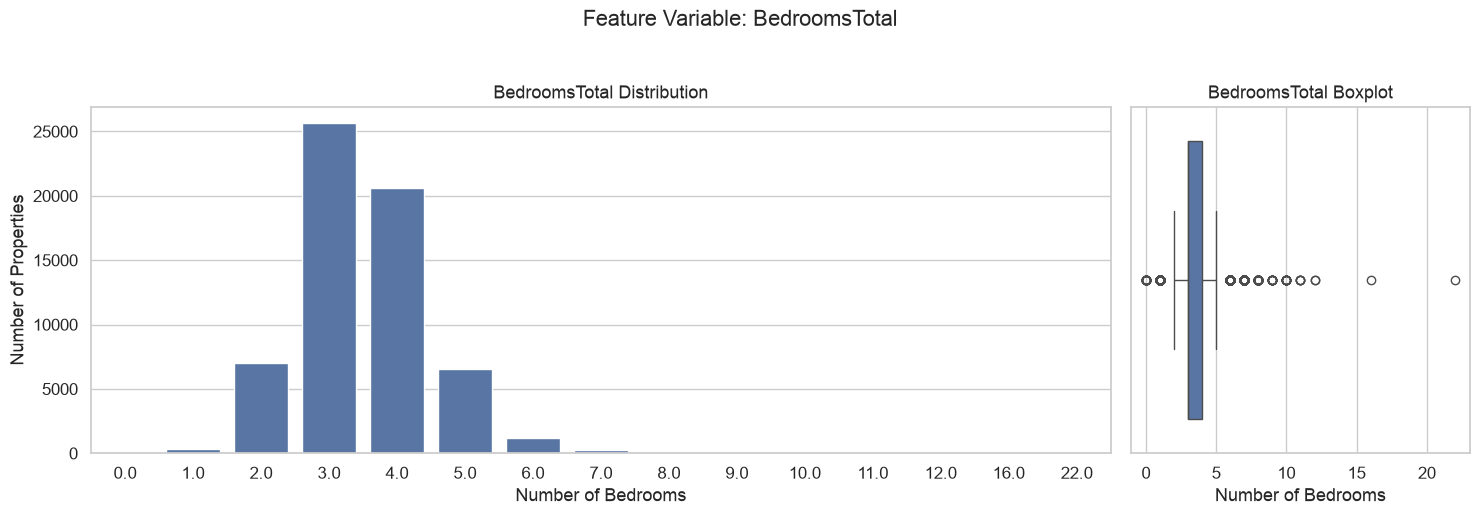

In [25]:
bedroom_plot = df["BedroomsTotal"].dropna()

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.countplot(
    data=df,
    x="BedroomsTotal",
    ax=axes[0]
)

axes[0].set_title("BedroomsTotal Distribution")
axes[0].set_xlabel("Number of Bedrooms")
axes[0].set_ylabel("Number of Properties")

sns.boxplot(
    x=bedroom_plot,
    ax=axes[1]
)

axes[1].set_title("BedroomsTotal Boxplot")
axes[1].set_xlabel("Number of Bedrooms")

fig.suptitle("Feature Variable: BedroomsTotal", y=1.03)
plt.tight_layout()
plt.show()

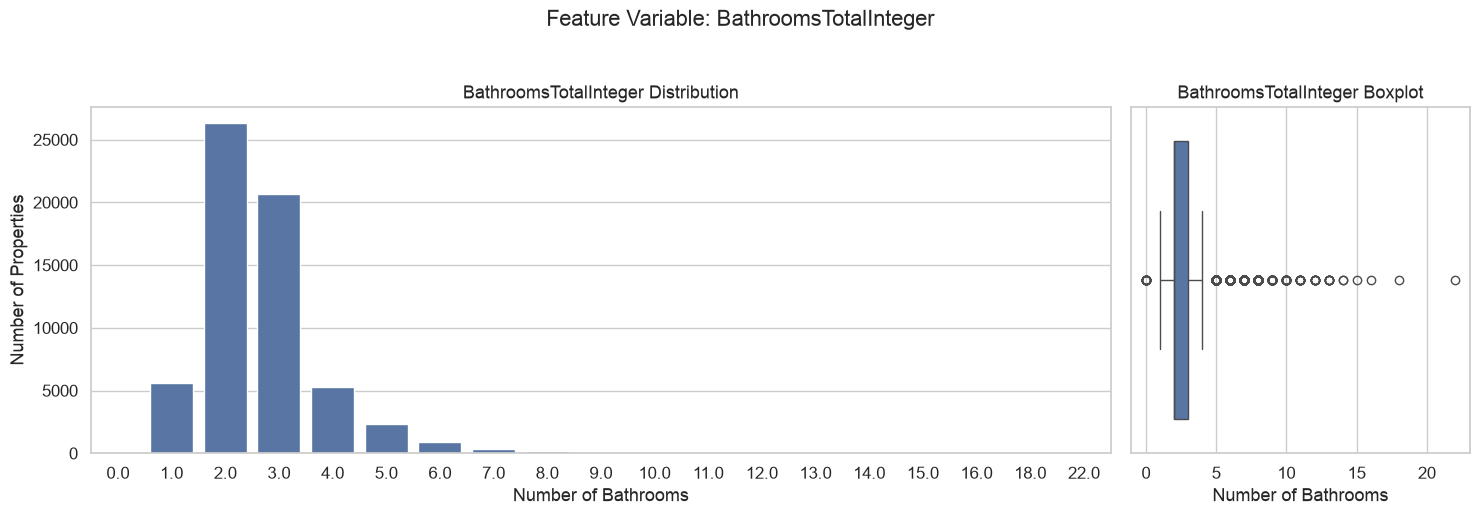

In [26]:
bathroom_plot = df["BathroomsTotalInteger"].dropna()

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.countplot(
    data=df,
    x="BathroomsTotalInteger",
    ax=axes[0]
)

axes[0].set_title("BathroomsTotalInteger Distribution")
axes[0].set_xlabel("Number of Bathrooms")
axes[0].set_ylabel("Number of Properties")

sns.boxplot(
    x=bathroom_plot,
    ax=axes[1]
)

axes[1].set_title("BathroomsTotalInteger Boxplot")
axes[1].set_xlabel("Number of Bathrooms")

fig.suptitle("Feature Variable: BathroomsTotalInteger", y=1.03)
plt.tight_layout()
plt.show()

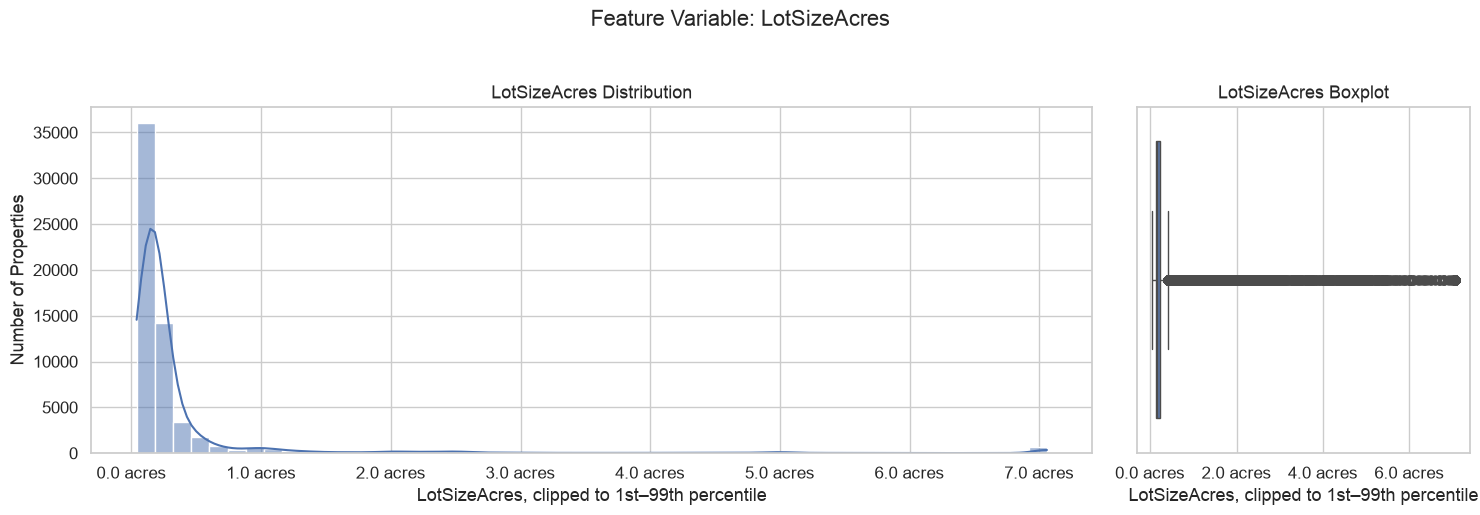

LotSizeAcres 1st percentile: 0.04 acres
LotSizeAcres 99th percentile: 7.06 acres


In [27]:
lot_plot, lot_p01, lot_p99 = clipped_series(df["LotSizeAcres"])

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.histplot(
    lot_plot,
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("LotSizeAcres Distribution")
axes[0].set_xlabel("LotSizeAcres, clipped to 1st–99th percentile")
axes[0].set_ylabel("Number of Properties")
acres_ticks(axes[0].xaxis)

sns.boxplot(
    x=lot_plot,
    ax=axes[1]
)

axes[1].set_title("LotSizeAcres Boxplot")
axes[1].set_xlabel("LotSizeAcres, clipped to 1st–99th percentile")
acres_ticks(axes[1].xaxis)

fig.suptitle("Feature Variable: LotSizeAcres", y=1.03)
plt.tight_layout()
plt.show()

print(f"LotSizeAcres 1st percentile: {lot_p01:.2f} acres")
print(f"LotSizeAcres 99th percentile: {lot_p99:.2f} acres")